# Day 3: EDA (reference solution)

NOTE: written without access to the dataset; run it once against the real file
and confirm the numbers quoted in the lesson plan and answer key.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../../../student/data/creditcard.csv")

## 1. First look

In [2]:
print(df.shape)
print(df.dtypes.value_counts())
print("missing:", df.isna().sum().sum())
print("duplicates:", df.duplicated().sum())

(284807, 31)
float64    30
int64       1
Name: count, dtype: int64
missing: 0
duplicates: 1081


## 2. Class balance

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64
always-not-fraud accuracy: 0.9982725143693799


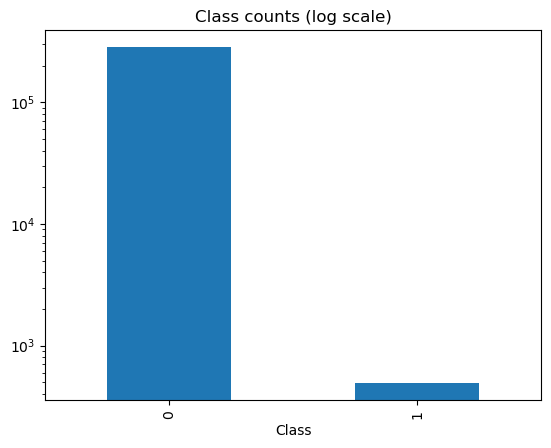

In [3]:
counts = df["Class"].value_counts()
print(counts)
print(df["Class"].value_counts(normalize=True) * 100)
print("always-not-fraud accuracy:", counts[0] / len(df))
ax = counts.plot.bar(logy=True)
ax.set_title("Class counts (log scale)")
plt.show()

## 3. Amount

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


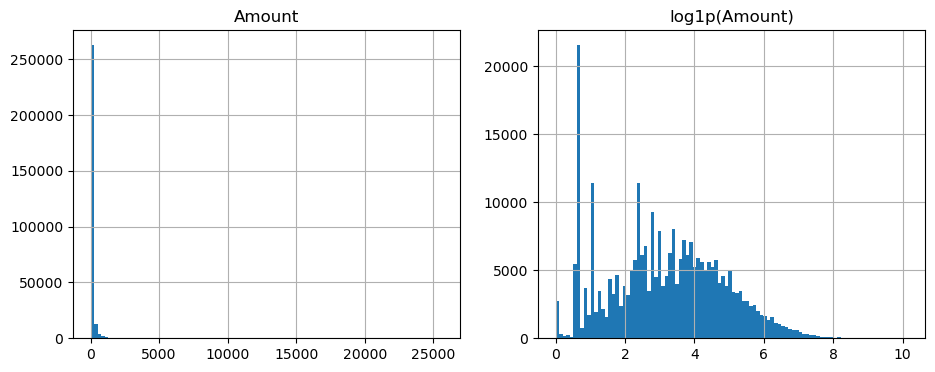

In [4]:
print(df["Amount"].describe())
print(df.groupby("Class")["Amount"].describe())
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["Amount"].hist(bins=100, ax=axes[0]); axes[0].set_title("Amount")
np.log1p(df["Amount"]).hist(bins=100, ax=axes[1]); axes[1].set_title("log1p(Amount)")
plt.show()

## 4. Time: seconds since the first transaction, not clock time

47.99777777777778 hours of data


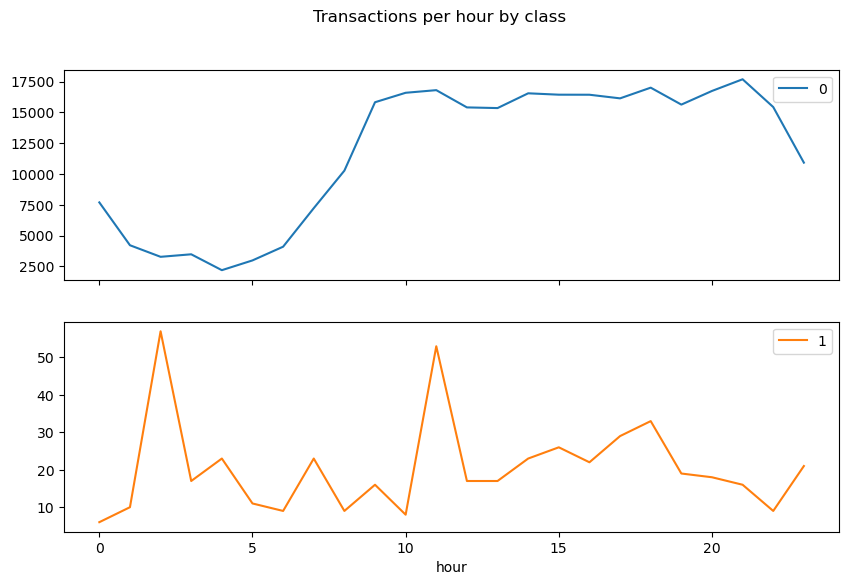

hour
0.0     0.00078
1.0     0.00237
2.0     0.01713
3.0     0.00487
4.0     0.01041
5.0     0.00368
6.0     0.00219
7.0     0.00318
8.0     0.00088
9.0     0.00101
10.0    0.00048
11.0    0.00314
12.0    0.00110
13.0    0.00111
14.0    0.00139
15.0    0.00158
16.0    0.00134
17.0    0.00179
18.0    0.00194
19.0    0.00121
20.0    0.00107
21.0    0.00090
22.0    0.00058
23.0    0.00192
dtype: float64


In [5]:
print(df["Time"].max() / 3600, "hours of data")
df["hour"] = (df["Time"] // 3600) % 24
by_hour = df.groupby(["hour", "Class"]).size().unstack(fill_value=0)
by_hour.plot(subplots=True, figsize=(10, 6), title="Transactions per hour by class")
plt.show()
print((by_hour[1] / by_hour.sum(axis=1)).round(5))  # fraud share by hour

## 5. V1-V28

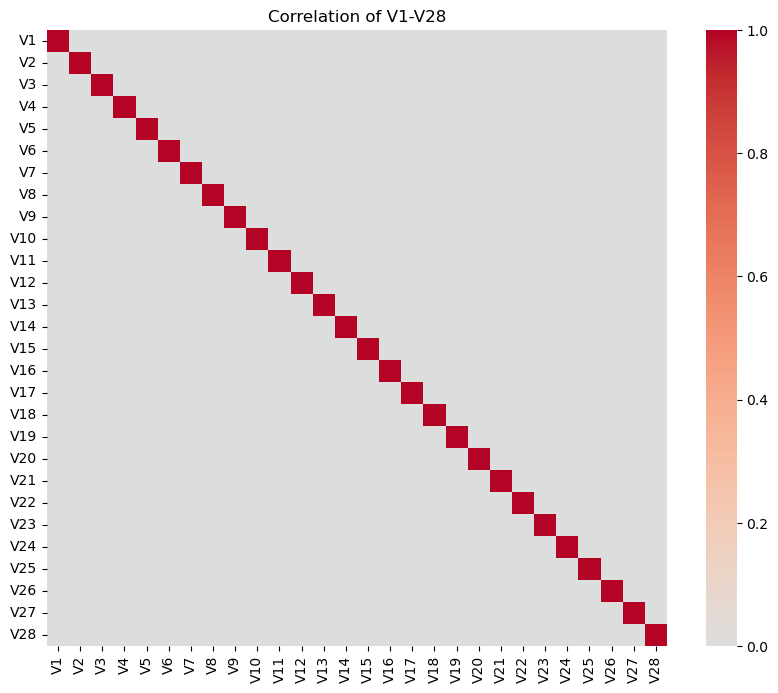

V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V18   -0.111485
V1    -0.101347
V9    -0.097733
V5    -0.094974
V6    -0.043643
V24   -0.007221
V13   -0.004570
V15   -0.004223
V23   -0.002685
V22    0.000805
V25    0.003308
V26    0.004455
V28    0.009536
V27    0.017580
V8     0.019875
V20    0.020090
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
dtype: float64


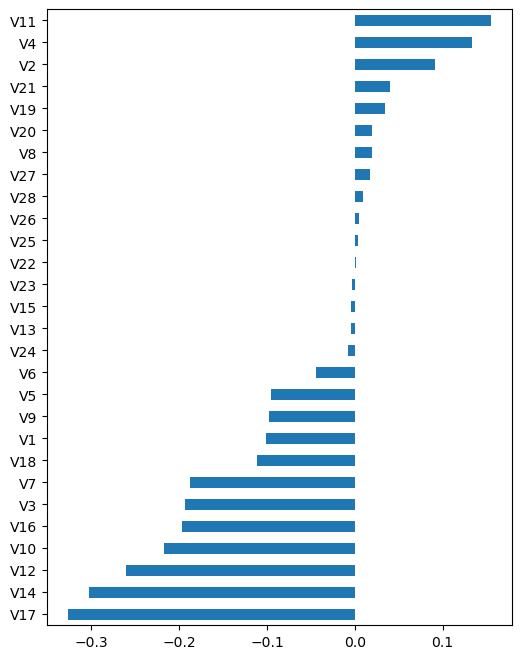

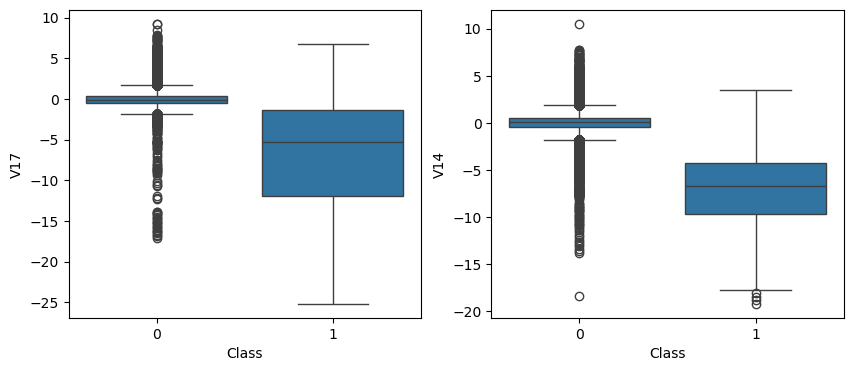

In [6]:
v = [f"V{i}" for i in range(1, 29)]
plt.figure(figsize=(10, 8))
sns.heatmap(df[v].corr(), cmap="coolwarm", center=0)
plt.title("Correlation of V1-V28")
plt.show()

corr_class = df[v].corrwith(df["Class"]).sort_values()
print(corr_class)
corr_class.plot.barh(figsize=(6, 8))
plt.show()

top = corr_class.abs().sort_values(ascending=False).index[:2]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, top):
    sns.boxplot(data=df, x="Class", y=col, ax=ax)
plt.show()